# Image Captioning — Inference

This notebook demonstrates the inference pipeline for the trained CNN–RNN image captioning model.

The model generates natural-language captions for unseen images by combining:

- a **CNN encoder** to extract visual features from an input image
- an **LSTM decoder** to generate a caption token by token

## Inference Pipeline

1. Prepare the test data loader
2. Load the trained encoder and decoder
3. Generate caption tokens with the decoder
4. Convert token IDs back to words
5. Visualize the input image and generated caption

## Step 1: Prepare the Test Data Loader

Before running inference, define the preprocessing pipeline for the test images.

The test images should use the same normalization parameters as the training data to ensure consistency with the pretrained CNN encoder.

Unlike the training pipeline, random data augmentation is not applied during inference because predictions should be deterministic.

In [15]:
import sys
from pathlib import Path

from torchvision import transforms

# ---------------------------------------------------------
# Project paths
# ---------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent
COCO_ROOT = (Path.cwd() / "../../COCOapi").resolve()

# Allow imports from the project's src package.
sys.path.insert(0, str(PROJECT_ROOT))

# ---------------------------------------------------------
# Project modules
# ---------------------------------------------------------

from src.data_loader import get_loader


# ---------------------------------------------------------
# Image preprocessing for inference
# ---------------------------------------------------------

transform_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.485, 0.456, 0.406),
        (0.229, 0.224, 0.225),
    ),
])


# ---------------------------------------------------------
# Test data loader
# ---------------------------------------------------------

data_loader = get_loader(
    transform=transform_test,
    mode="test",
    cocoapi_loc=str(COCO_ROOT)
)

Vocabulary successfully loaded from ./vocab.pkl.


Run the code cell below to visualize an example test image, before pre-processing is applied.

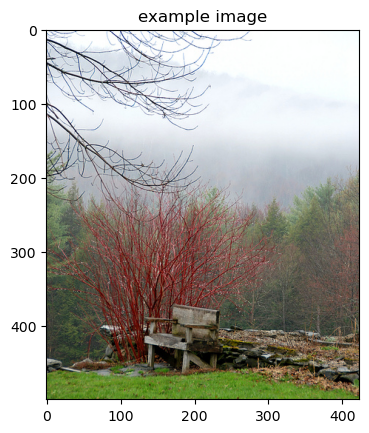

In [16]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Obtain sample image before and after pre-processing.
orig_image, image = next(iter(data_loader))

# Visualize sample image, before pre-processing.
plt.imshow(np.squeeze(orig_image))
plt.title('example image')
plt.show()

<a id='step2'></a>

## Step 2: Load the Trained Models

Before loading the trained encoder and decoder, configure the PyTorch device used for inference.

The device is selected automatically based on the available hardware:

- **CUDA** — uses an NVIDIA GPU when CUDA is available.
- **MPS** — uses the Apple GPU through Metal Performance Shaders on Apple Silicon.
- **CPU** — used as a fallback when GPU acceleration is unavailable.

The selected device will be used to move both the model parameters and input tensors to the same computing device during inference.

In [17]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


### Load Model Checkpoints

The trained CNN encoder and LSTM decoder are restored from the checkpoints saved during training.

For inference, the final checkpoints from **epoch 3** are used:

- `models/encoder-3.pt`
- `models/decoder-3.pt`

The model architecture must match the configuration used during training. In particular, the decoder is reconstructed using the same embedding and hidden-state dimensions:

- **Embedding size:** `256`
- **Hidden size:** `256`

After initializing the encoder and decoder with the original architecture, the saved model parameters are loaded into each network.

Both models are then moved to the selected device and switched to **evaluation mode** using `model.eval()` before generating captions.

In [18]:
import torch

from src.model import EncoderCNN, DecoderRNN


# ---------------------------------------------------------
# Model configuration
# ---------------------------------------------------------

embed_size = 256
hidden_size = 256
vocab_size = len(data_loader.dataset.vocab)


# ---------------------------------------------------------
# Model checkpoint paths
# ---------------------------------------------------------

MODEL_DIR = Path.cwd() / "models"

encoder_file = MODEL_DIR / "encoder-3.pt"
decoder_file = MODEL_DIR / "decoder-3.pt"


# ---------------------------------------------------------
# Initialize models
# ---------------------------------------------------------

encoder = EncoderCNN(embed_size)
decoder = DecoderRNN(embed_size, hidden_size, vocab_size)


# ---------------------------------------------------------
# Load trained weights
# ---------------------------------------------------------

encoder.load_state_dict(
    torch.load(encoder_file, map_location=device)
)

decoder.load_state_dict(
    torch.load(decoder_file, map_location=device)
)


# ---------------------------------------------------------
# Prepare models for inference
# ---------------------------------------------------------

encoder = encoder.to(device)
decoder = decoder.to(device)

encoder.eval()
decoder.eval()

print("Trained encoder and decoder loaded successfully.")

Trained encoder and decoder loaded successfully.


<a id='step3'></a>

## Step 3: Implement the Caption Sampler

The decoder generates an image caption **autoregressively**, predicting one word at a time based on the encoded image features and the previously generated words.

The `sample()` method in `DecoderRNN` performs the caption generation process. It receives the encoded image features from the CNN encoder and repeatedly passes them through the LSTM decoder to predict the next token.

### Caption Generation Process

At each decoding step:

1. Pass the current input and hidden state through the LSTM.
2. Project the LSTM output to vocabulary logits using the fully connected layer.
3. Select the token with the highest predicted score.
4. Store the predicted token ID.
5. Convert the predicted token into an embedding and use it as the input to the next decoding step.
6. Continue until the `<end>` token is generated or the maximum sequence length is reached.

The generated output is a sequence of vocabulary indices:

`[<start>, word₁, word₂, ..., wordₙ, <end>]`

Each predicted index can be converted back to its corresponding word using:

`data_loader.dataset.vocab.idx2word`

This transforms the model output from token IDs into a human-readable caption.

In [19]:
# Move the input image tensor to the selected device.
image = image.to(device)

# Disable gradient computation during inference.
with torch.no_grad():

    # Extract visual features using the CNN encoder.
    features = encoder(image).unsqueeze(1)

    # Generate a caption by sampling tokens from the decoder.
    output = decoder.sample(features)

print("Example output:", output)

# Validate the generated token sequence.
assert isinstance(output, list), \
    "Output must be a Python list."

assert all(isinstance(x, int) for x in output), \
    "Each output element must be an integer token ID."

assert all(x in data_loader.dataset.vocab.idx2word for x in output), \
    "Each token ID must exist in the vocabulary."

Example output: [0, 3, 855, 130, 818, 54, 32, 2486, 79, 3, 1394, 18, 1, 18, 1, 18, 1, 18, 1, 18]


<a id='step4'></a>

## Step 4: Convert Token IDs to a Caption

The decoder returns the generated caption as a sequence of vocabulary token IDs.

To produce a human-readable caption, the `clean_sentence()` function converts each token ID back to its corresponding word using the vocabulary mapping.

During this process:

1. Convert each token ID to a word using `vocab.idx2word`.
2. Ignore the `<start>` token because it only represents the beginning of the sequence.
3. Stop processing when the `<end>` token is encountered.
4. Join the remaining words into a single sentence.

This converts the raw decoder output into the final generated caption.

In [20]:
def clean_sentence(output):
    """Convert generated token IDs into a readable caption."""

    words = []
    vocab = data_loader.dataset.vocab

    for token_id in output:
        word = vocab.idx2word[token_id]

        # Stop once the end-of-sequence token is generated.
        if word == "<end>":
            break

        # Skip the start-of-sequence token.
        if word != "<start>":
            words.append(word)

    return " ".join(words)

After completing the `clean_sentence` function above, run the code cell below.  If the cell returns an assertion error, then please follow the instructions to modify your code before proceeding.

In [21]:
sentence = clean_sentence(output)
print('example sentence:', sentence)

assert type(sentence)==str, 'Sentence needs to be a Python string!'

example sentence: a train is traveling down the tracks near a forest .


<a id='step5'></a>

## Step 5: Generate Image Captions

The complete inference pipeline is now used to generate captions for unseen images from the COCO test dataset.

For each test image, the pipeline performs the following steps:

1. Load and preprocess an image from the test dataset.
2. Move the image tensor to the selected computing device.
3. Extract visual features using the CNN encoder.
4. Pass the encoded features to the LSTM decoder.
5. Generate a sequence of predicted token IDs.
6. Convert the token sequence into a human-readable caption.
7. Display the original image together with the generated caption.

The `get_prediction()` function combines these steps into a single inference workflow, allowing the trained model to generate captions for different test images.

In [22]:
import matplotlib.pyplot as plt


def get_prediction():
    """Generate and display a caption for a test image."""

    # Load a test image and its preprocessed tensor.
    orig_image, image = next(iter(data_loader))

    # Move the image tensor to the selected device.
    image = image.to(device)

    # Generate a caption without computing gradients.
    with torch.no_grad():
        features = encoder(image).unsqueeze(1)
        output = decoder.sample(features)

    # Convert predicted token IDs into a readable caption.
    sentence = clean_sentence(output)

    # Remove the batch dimension before visualization.
    display_image = orig_image.squeeze(0)

    # Display the original image and generated caption.
    plt.imshow(display_image)
    plt.axis("off")
    plt.title(sentence)
    plt.show()

    print(f"Generated caption: {sentence}")

Run the code cell below (multiple times, if you like!) to test how this function works.

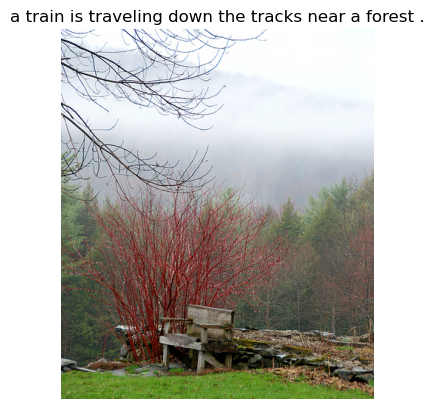

Generated caption: a train is traveling down the tracks near a forest .


In [23]:
get_prediction()

As the last task in this project, you will loop over the images until you find four image-caption pairs of interest:
- Two should include image-caption pairs that show instances when the model performed well.
- Two should highlight image-caption pairs that highlight instances where the model did not perform well.

Use the four code cells below to complete this task.

### The model performed well!

Use the next two code cells to loop over captions.  Save the notebook when you encounter two images with relatively accurate captions.

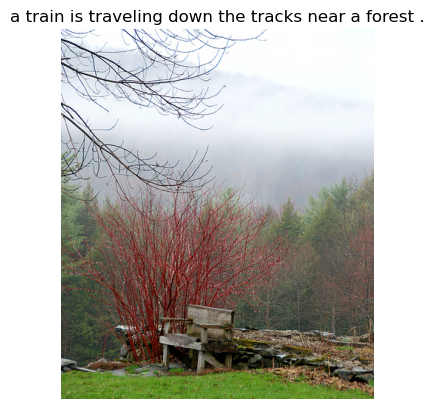

Generated caption: a train is traveling down the tracks near a forest .


In [24]:
get_prediction()

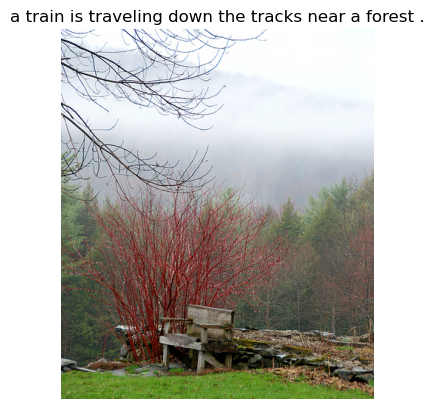

Generated caption: a train is traveling down the tracks near a forest .


In [25]:
get_prediction()

### The model could have performed better ...

Use the next two code cells to loop over captions.  Save the notebook when you encounter two images with relatively inaccurate captions.

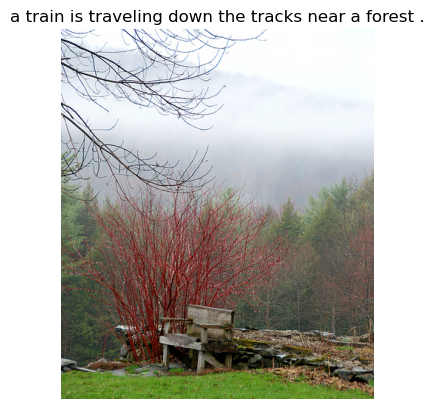

Generated caption: a train is traveling down the tracks near a forest .


In [26]:
get_prediction()

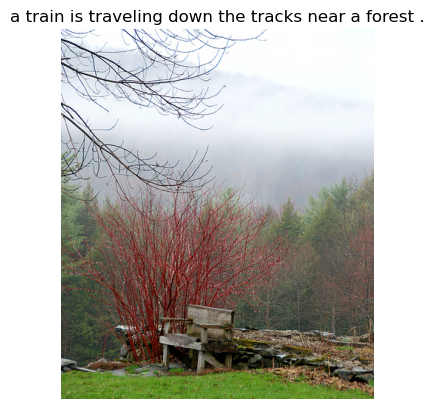

Generated caption: a train is traveling down the tracks near a forest .


In [27]:
get_prediction()